In [122]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from numpy.typing import NDArray


from metastable.state import FixedPointMap
from metastable.eom import EOM, Params
from metastable.incoming_quantum_vector import extend_to_keldysh_state


def calculate(
    keldysh_fixed_point: NDArray[float], params: Params):
    """Find the inverse of the manifold spanned by the unstable eigenvectors of the jacobian at the saddle point. These
    vectors are orthogonal to the stable manifold, so they can be used to define the boundary condition at the saddle
    point."""
    eom = EOM(params=params)
    jacobian = eom.jacobian_func(keldysh_fixed_point)
    eigenvalues, eigenvectors = np.linalg.eig(jacobian)
    inverse_eigenvectors = np.linalg.inv(eigenvectors)
    return eigenvalues, eigenvectors, inverse_eigenvectors
    

fixed_point_map = FixedPointMap.load("/home/paul/Projects/keldysh/metastable/scratch/map.npz")
epsilon_idx = 50
kappa_idx = 20
params = Params(
    epsilon=fixed_point_map.epsilon_linspace[epsilon_idx],
    kappa=fixed_point_map.kappa_linspace[kappa_idx],
    delta=fixed_point_map.delta,
    chi=fixed_point_map.chi,
)
eom = EOM(params=params)
classical_saddle_point = fixed_point_map.fixed_points[epsilon_idx, kappa_idx, 0]
classical_focus_point = fixed_point_map.fixed_points[epsilon_idx, kappa_idx, 1]
print(fixed_point_map.epsilon_linspace.shape)
print(fixed_point_map.kappa_linspace.shape)
print(params)
print(classical_saddle_point, classical_focus_point)


keldysh_saddle_point = extend_to_keldysh_state(classical_saddle_point)
keldysh_focus_point = extend_to_keldysh_state(classical_focus_point)

saddle_eigenvalues, saddle_eigenvectors, saddle_inverse_eigenvectors = calculate(keldysh_saddle_point, params)
focus_eigenvalues, focus_eigenvectors, focus_inverse_eigenvectors = calculate(keldysh_focus_point, params)

(51,)
(31,)
epsilon=10.0 delta=7.8 chi=-0.1 kappa=1.0
[-6.33055006  9.30242641] [-8.91507454 -9.94097263]


In [123]:
def find_path(eom, focus_constraint_vectors, saddle_constraint_vectors, t_guess, y_guess):
    def boundary_condition_func(ya, yb):
        return np.hstack(
            [
                np.abs(np.dot(focus_constraint_vectors, ya - keldysh_focus_point)),
                np.abs(np.dot(saddle_constraint_vectors, yb - keldysh_saddle_point)),
            ]
        )
    wrapper = lambda x, y: eom.y_dot_func(y)
    res = scipy.integrate.solve_bvp(
        wrapper, boundary_condition_func, t_guess, y_guess, tol=3e-14, max_nodes=1000000
    )
    
    return res

In [124]:
saddle_constraint_vectors = saddle_inverse_eigenvectors[[0,3],:]
focus_constraint_vectors = focus_inverse_eigenvectors[[0,1],:] + np.dot(np.array([[0,1],[-1,0]]), focus_inverse_eigenvectors[[0,1],:])
t_guess = np.linspace(0.0, 8.0, 10001)
y_guess = (
    keldysh_focus_point[:, np.newaxis]
    + t_guess[np.newaxis, :]
    * (keldysh_saddle_point - keldysh_focus_point)[:, np.newaxis]
    / t_guess[-1]
)
res = find_path(eom, focus_constraint_vectors, saddle_constraint_vectors, t_guess, y_guess)

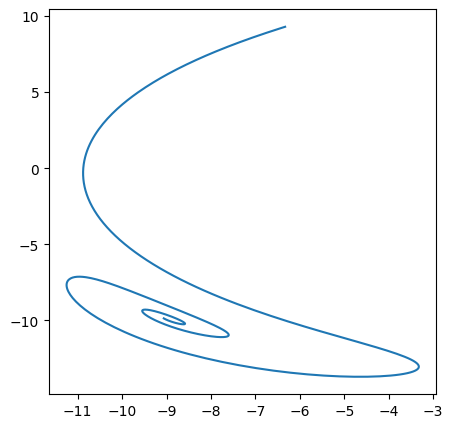

In [125]:
fig, axes = plt.subplots(1,1,figsize=(5, 5))
t_plot = np.linspace(0, t_guess[-1], 1001)
y0_plot = res.sol(t_plot)[0]
y1_plot = res.sol(t_plot)[1]
axes.plot(y0_plot,y1_plot)
plt.show()

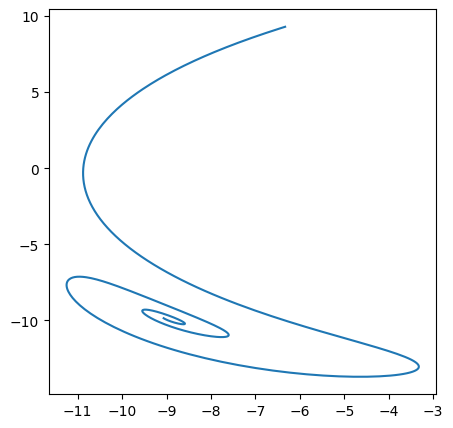

In [126]:
saddle_constraint_vectors = saddle_inverse_eigenvectors[[0,3],:]
focus_constraint_vectors = focus_inverse_eigenvectors[[0,1],:]
y_guess = res.sol(t_guess)
res = find_path(eom, focus_constraint_vectors, saddle_constraint_vectors, t_guess, y_guess)

fig, axes = plt.subplots(1,1,figsize=(5, 5))
t_plot = np.linspace(0, t_guess[-1], 1001)
y0_plot = res.sol(t_plot)[0]
y1_plot = res.sol(t_plot)[1]
axes.plot(y0_plot,y1_plot)
plt.show()

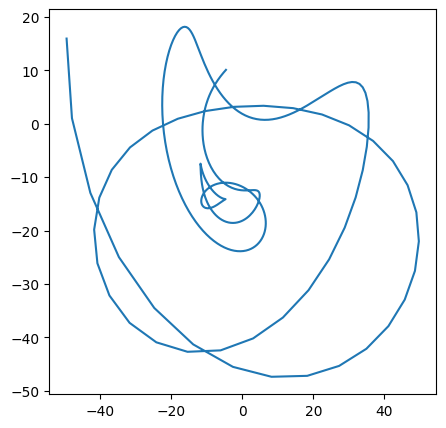

In [133]:
epsilon_idx = 50
kappa_idx = 15
params = Params(
    epsilon=fixed_point_map.epsilon_linspace[epsilon_idx],
    kappa=fixed_point_map.kappa_linspace[kappa_idx],
    delta=fixed_point_map.delta,
    chi=fixed_point_map.chi,
)
eom = EOM(params=params)
classical_saddle_point = fixed_point_map.fixed_points[epsilon_idx, kappa_idx, 0]
classical_focus_point = fixed_point_map.fixed_points[epsilon_idx, kappa_idx, 1]
keldysh_saddle_point = extend_to_keldysh_state(classical_saddle_point)
keldysh_focus_point = extend_to_keldysh_state(classical_focus_point)


saddle_eigenvalues, saddle_eigenvectors, saddle_inverse_eigenvectors = calculate(keldysh_saddle_point, params)
focus_eigenvalues, focus_eigenvectors, focus_inverse_eigenvectors = calculate(keldysh_focus_point, params)
saddle_constraint_vectors = saddle_inverse_eigenvectors[[0,3],:]
focus_constraint_vectors = focus_inverse_eigenvectors[[0,1],:]

y_guess = res.sol(t_guess)
res = find_path(eom, focus_constraint_vectors, saddle_constraint_vectors, t_guess, y_guess)
fig, axes = plt.subplots(1,1,figsize=(5, 5))
t_plot = np.linspace(0, t_guess[-1], 1001)
y0_plot = res.sol(t_plot)[0]
y1_plot = res.sol(t_plot)[1]
axes.plot(y0_plot,y1_plot)
plt.show()

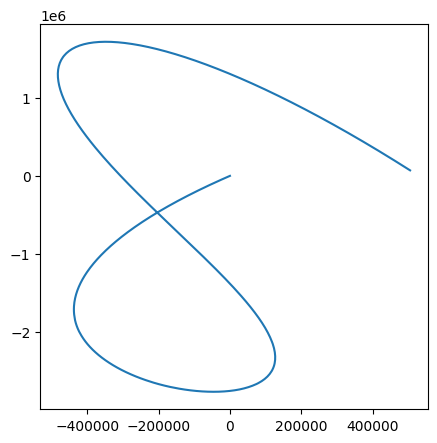

In [75]:
saddle_constraint_vectors = saddle_inverse_eigenvectors[[0,1,3],:]
focus_constraint_vectors = (focus_inverse_eigenvectors[[0],:] + focus_inverse_eigenvectors[[1],:]).real
y_guess = res.sol(t_guess)
res = find_path(eom, focus_constraint_vectors, saddle_constraint_vectors, t_guess, y_guess)
fig, axes = plt.subplots(1,1,figsize=(5, 5))
t_plot = np.linspace(0, t_guess[-1], 1001)
y0_plot = res.sol(t_plot)[0]
y1_plot = res.sol(t_plot)[1]
axes.plot(y0_plot,y1_plot)
plt.show()

In [ ]:
y_guess = res.sol(t_guess)
res = find_path(eom, focus_constraint_vectors, saddle_constraint_vectors, t_guess, y_guess)
fig, axes = plt.subplots(1,1,figsize=(5, 5))
t_plot = np.linspace(0, t_guess[-1], 1001)
y0_plot = res.sol(t_plot)[0]
y1_plot = res.sol(t_plot)[1]
axes.plot(y0_plot,y1_plot)
plt.show()

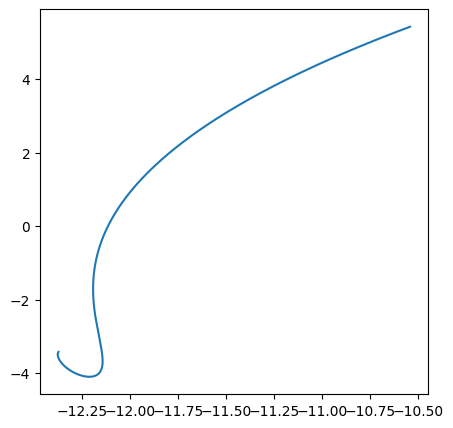

In [58]:
def boundary_condition_func(ya, yb):
    return np.hstack(
        [
            np.abs(np.dot(focus_constraint_vectors, ya - keldysh_focus_point)),
            np.abs(np.dot(saddle_constraint_vectors, yb - keldysh_saddle_point)),
        ]
    )


t_guess = np.linspace(0.0, 8.0, 10001)
y_guess = (
    keldysh_focus_point[:, np.newaxis]
    + t_guess[np.newaxis, :]
    * (keldysh_saddle_point - keldysh_focus_point)[:, np.newaxis]
    / t_guess[-1]
)
wrapper = lambda x, y: eom.y_dot_func(y)
res = scipy.integrate.solve_bvp(
    wrapper, boundary_condition_func, t_guess, y_guess, tol=3e-14, max_nodes=1000000
)


import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,1,figsize=(5, 5))
t_plot = np.linspace(0, t_guess[-1], 1001)
y0_plot = res.sol(t_plot)[0]
y1_plot = res.sol(t_plot)[1]
axes.plot(y0_plot,y1_plot)
plt.show()

In [2]:
jacobian = eom.jacobian_func(keldysh_saddle_point)
eigenvalues, eigenvectors = np.linalg.eig(jacobian)

In [3]:
eigenvalues

array([ 3.05531376, -5.05531376, -3.05531376,  5.05531376])

In [4]:
eigenvectors

array([[ 0.96893695,  0.5856029 ,  0.62753794,  0.69977946],
       [ 0.24730788,  0.81059808,  0.57563704,  0.03292539],
       [ 0.        ,  0.        , -0.4249561 ,  0.17647885],
       [ 0.        ,  0.        ,  0.30700236, -0.69143318]])

In [11]:
fixed_point_map = FixedPointMap.load("/home/paul/Projects/keldysh/metastable/scratch/map.npz")
epsilon_idx = 10
kappa_idx = 0
params = Params(
    epsilon=fixed_point_map.epsilon_linspace[epsilon_idx],
    kappa=fixed_point_map.kappa_linspace[kappa_idx],
    delta=fixed_point_map.delta,
    chi=fixed_point_map.chi,
)
eom = EOM(params=params)
classical_saddle_point = fixed_point_map.fixed_points[epsilon_idx, kappa_idx, 0]
classical_focus_point = fixed_point_map.fixed_points[epsilon_idx, kappa_idx, 1]
print(fixed_point_map.epsilon_linspace.shape)
print(fixed_point_map.kappa_linspace.shape)
print(params)
print(classical_saddle_point, classical_focus_point)


keldysh_saddle_point = extend_to_keldysh_state(classical_saddle_point)
keldysh_focus_point = extend_to_keldysh_state(classical_focus_point)

(51,)
(31,)
epsilon=2.0 delta=7.8 chi=-0.1 kappa=0.0
[-1.95590899e-13  1.22252261e+01] [ 2.33263653e-16 -1.27389156e+01]


In [12]:
jacobian = eom.jacobian_func(keldysh_focus_point)
eigenvalues, eigenvectors = np.linalg.eig(jacobian)

In [13]:
eigenvalues

array([0.+2.27907026j, 0.-2.27907026j, 0.+2.27907026j, 0.-2.27907026j])

In [14]:
eigenvectors

array([[-9.90642066e-01+0.j        , -9.90642066e-01-0.j        ,
         0.00000000e+00+0.j        ,  0.00000000e+00-0.j        ],
       [-1.77954265e-17+0.13648552j, -1.77954265e-17-0.13648552j,
         0.00000000e+00+0.j        ,  0.00000000e+00-0.j        ],
       [ 0.00000000e+00+0.j        ,  0.00000000e+00-0.j        ,
         1.77954265e-17-0.13648552j,  1.77954265e-17+0.13648552j],
       [ 0.00000000e+00+0.j        ,  0.00000000e+00-0.j        ,
        -9.90642066e-01+0.j        , -9.90642066e-01-0.j        ]])

In [15]:
jacobian = eom.jacobian_func(keldysh_saddle_point)
eigenvalues, eigenvectors = np.linalg.eig(jacobian)

In [16]:
eigenvalues

array([ 2.18701524, -2.18701524, -2.18701524,  2.18701524])

In [17]:
eigenvectors

array([[ 0.98899333,  0.98899333,  0.        ,  0.        ],
       [-0.14796011,  0.14796011,  0.        ,  0.        ],
       [ 0.        ,  0.        , -0.14796011, -0.14796011],
       [ 0.        ,  0.        ,  0.98899333, -0.98899333]])

In [ ]:
x0_reciprocal
x1_reciprocal

The boundary condiation is:

x0_reciprocal . displacement = 0
x1_reciprocal . displacement = 0

In [ ]:
x_k_reciprocal . x_j_reciprocal = delta_kj 

The boundary is that the displacement close to the focus has at least some outgoing component i.e. it has at least some of either eigenvector_2 or eigenvector_3.

Also, the displacement must be real. Since eigenvector_0 and eigenvector_1 are both purely classical, the imaginary components eigenvevector_2 and eigenvector_3 can only be cancelled by each other. So the displacement must have at least some of BOTH eignevector_2 and eigenvector_3.



(51,)
(31,)
epsilon=10.0 delta=7.8 chi=-0.1 kappa=1.0
[-6.33055006  9.30242641] [-8.91507454 -9.94097263]


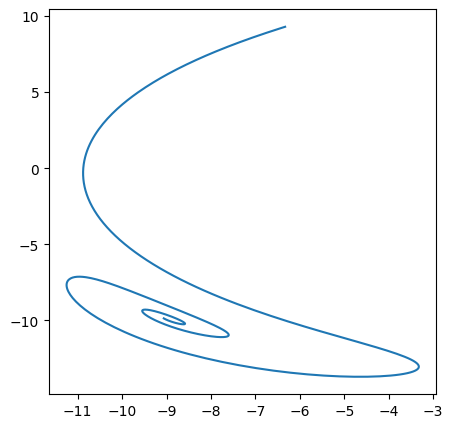

In [2]:
import numpy as np
import scipy


from metastable.state import FixedPointMap
from metastable.eom import EOM, Params
from metastable.manifold_inverses import calculate_manifold_inverses
from metastable.incoming_quantum_vector import extend_to_keldysh_state


fixed_point_map = FixedPointMap.load("/home/paul/Projects/keldysh/metastable/scratch/map.npz")
epsilon_idx = -1
kappa_idx = 20
params = Params(
    epsilon=fixed_point_map.epsilon_linspace[epsilon_idx],
    kappa=fixed_point_map.kappa_linspace[kappa_idx],
    delta=fixed_point_map.delta,
    chi=fixed_point_map.chi,
)
eom = EOM(params=params)
classical_saddle_point = fixed_point_map.fixed_points[epsilon_idx, kappa_idx, 0]
classical_focus_point = fixed_point_map.fixed_points[epsilon_idx, kappa_idx, 1]
print(fixed_point_map.epsilon_linspace.shape)
print(fixed_point_map.kappa_linspace.shape)
print(params)
print(classical_saddle_point, classical_focus_point)


keldysh_saddle_point = extend_to_keldysh_state(classical_saddle_point)
keldysh_focus_point = extend_to_keldysh_state(classical_focus_point)
_, saddle_point_unstable_manifold_inverse = calculate_manifold_inverses(
    keldysh_saddle_point, params
)
focus_point_stable_manifold_inverse, _ = calculate_manifold_inverses(
    keldysh_focus_point, params
)
focus_point_bc_vectors = focus_point_stable_manifold_inverse + np.dot(np.array([[0,1],[-1,0]]),focus_point_stable_manifold_inverse)

def bc(ya, yb):
    return np.hstack(
        [
            np.abs(np.dot(focus_point_bc_vectors, ya - keldysh_focus_point)),
            np.abs(np.dot(saddle_point_unstable_manifold_inverse, yb - keldysh_saddle_point)),
        ]
    )


t_guess = np.linspace(0.0, 8.0, 10001)
y_guess = (
    keldysh_focus_point[:, np.newaxis]
    + t_guess[np.newaxis, :]
    * (keldysh_saddle_point - keldysh_focus_point)[:, np.newaxis]
    / t_guess[-1]
)
wrapper = lambda x, y: eom.y_dot_func(y)
res = scipy.integrate.solve_bvp(
    wrapper, bc, t_guess, y_guess, tol=3e-14, max_nodes=1000000
)


import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,1,figsize=(5, 5))
t_plot = np.linspace(0, t_guess[-1], 1001)
y0_plot = res.sol(t_plot)[0]
y1_plot = res.sol(t_plot)[1]
axes.plot(y0_plot,y1_plot)
plt.show()


(51,)
(31,)
epsilon=10.0 delta=7.8 chi=-0.1 kappa=0.9500000000000001
[-5.97661493  9.49228877] [ -8.5060855  -10.33063375]


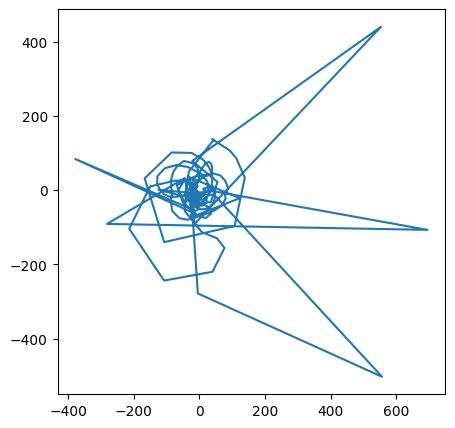

In [3]:
import numpy as np
import scipy


from metastable.state import FixedPointMap
from metastable.eom import EOM, Params
from metastable.manifold_inverses import calculate_manifold_inverses
from metastable.incoming_quantum_vector import extend_to_keldysh_state


fixed_point_map = FixedPointMap.load("/home/paul/Projects/keldysh/metastable/scratch/map.npz")
epsilon_idx = -1
kappa_idx = 19
params = Params(
    epsilon=fixed_point_map.epsilon_linspace[epsilon_idx],
    kappa=fixed_point_map.kappa_linspace[kappa_idx],
    delta=fixed_point_map.delta,
    chi=fixed_point_map.chi,
)
eom = EOM(params=params)
classical_saddle_point = fixed_point_map.fixed_points[epsilon_idx, kappa_idx, 0]
classical_focus_point = fixed_point_map.fixed_points[epsilon_idx, kappa_idx, 1]
print(fixed_point_map.epsilon_linspace.shape)
print(fixed_point_map.kappa_linspace.shape)
print(params)
print(classical_saddle_point, classical_focus_point)


keldysh_saddle_point = extend_to_keldysh_state(classical_saddle_point)
keldysh_focus_point = extend_to_keldysh_state(classical_focus_point)
_, saddle_point_unstable_manifold_inverse = calculate_manifold_inverses(
    keldysh_saddle_point, params
)
focus_point_stable_manifold_inverse, _ = calculate_manifold_inverses(
    keldysh_focus_point, params
)
focus_point_bc_vectors = focus_point_stable_manifold_inverse + np.dot(np.array([[0,1],[-1,0]]),focus_point_stable_manifold_inverse)

def bc(ya, yb):
    return np.hstack(
        [
            np.abs(np.dot(focus_point_bc_vectors, ya - keldysh_focus_point)),
            np.abs(np.dot(saddle_point_unstable_manifold_inverse, yb - keldysh_saddle_point)),
        ]
    )


t_guess = np.linspace(0.0, 8.5, 10001)
y_guess = (
    keldysh_focus_point[:, np.newaxis]
    + t_guess[np.newaxis, :]
    * (keldysh_saddle_point - keldysh_focus_point)[:, np.newaxis]
    / t_guess[-1]
)
wrapper = lambda x, y: eom.y_dot_func(y)
res = scipy.integrate.solve_bvp(
    wrapper, bc, t_guess, y_guess, tol=3e-14, max_nodes=2000000
)


import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,1,figsize=(5, 5))
t_plot = np.linspace(0, t_guess[-1], 1001)
y0_plot = res.sol(t_plot)[0]
y1_plot = res.sol(t_plot)[1]
axes.plot(y0_plot,y1_plot)
plt.show()
